# Analisis Exploratorio: Premier League 2025-26

Este notebook realiza un analisis inicial de los datos descargados de la API para preparar el modelado predictivo.

## Documentacion de la API (15 Endpoints)

### Core Data (FPL)
1. **`/players`**: Listado completo con filtros de posicion y equipo.
2. **`/players/{id}`**: Historial detallado de un jugador jornada a jornada.
3. **`/teams`**: Los 20 equipos con sus niveles de fuerza (ataque/defensa).
4. **`/teams/{id}`**: Plantillas y detalles especificos por equipo.
5. **`/gameweeks`**: Calendario de las 38 jornadas.
6. **`/gameweeks/{id}`**: Cruces especificos de una jornada.
7. **`/standings`**: Tabla de posiciones calculada en tiempo real.

### Match & Stats
8. **`/matches`**: Resultados historicos con estadisticas y cuotas (nuestra fuente principal).
9. **`/referees`**: Impacto y estadisticas de los arbitros.

### Event-Level Data (WhoScored)
10. **`/matches/{id}/events`**: Todos los eventos (pases, tiros) con coordenadas X,Y.
11. **`/matches/{id}/events/summary`**: Conteo rapido de tipos de eventos por partido.
12. **`/events`**: Buscador global de eventos por jugador o tipo.

### Metadata & Docs
13. **`/llms.txt`**: Instrucciones optimizadas para IA.
14. **`/docs`**: Interfaz Swagger interactiva.
15. **`/openapi.json`**: Especificacion tecnica de la API.

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Configurar rutas
DATA_PATH = "../data/matches.csv"

# Cargar datos
df = pd.read_csv(DATA_PATH)
print(f"Dataset cargado: {df.shape[0]} partidos, {df.shape[1]} columnas")

# --- Exploracion Rapida ---
print("Columnas:", df.columns.tolist())
print("\nDistribucion de resultados:")
print(df["ftr"].value_counts())
print(f"\nGoles por partido: {(df['fthg'] + df['ftag']).mean():.2f}")
# --------------------------

df.head()

Dataset cargado: 291 partidos, 41 columnas
Columnas: ['id', 'date', 'time', 'home_team', 'away_team', 'fthg', 'ftag', 'ftr', 'hthg', 'htag', 'htr', 'referee', 'hs', 'as_', 'hst', 'ast', 'hf', 'af', 'hc', 'ac', 'hy', 'ay', 'hr', 'ar', 'b365h', 'b365d', 'b365a', 'bwh', 'bwd', 'bwa', 'maxh', 'maxd', 'maxa', 'avgh', 'avgd', 'avga', 'total_goals', 'goal_diff', 'implied_prob_h', 'implied_prob_d', 'implied_prob_a']

Distribucion de resultados:
ftr
H    123
A     92
D     76
Name: count, dtype: int64

Goles por partido: 2.77


,id,date,time,home_team,away_team,fthg,ftag,ftr,hthg,htag,...,maxd,maxa,avgh,avgd,avga,total_goals,goal_diff,implied_prob_h,implied_prob_d,implied_prob_a
0,30,31/08/2025,19:00,Aston Villa,Crystal Palace,0,3,A,0,1,...,3.75,4.20,1.88,3.56,4.07,3,-3,0.541,0.270,0.250
1,29,31/08/2025,16:30,Liverpool,Arsenal,1,0,H,0,0,...,3.60,3.25,2.20,3.49,3.17,1,1,0.455,0.286,0.312
2,27,31/08/2025,14:00,Brighton,Man City,2,1,H,0,1,...,4.00,1.91,3.78,3.84,1.85,3,1,0.263,0.256,0.526
3,28,31/08/2025,14:00,Nott'm Forest,West Ham,0,3,A,0,0,...,3.85,5.50,1.69,3.74,5.03,3,-3,0.599,0.267,0.190
4,235,31/01/2026,20:00,Liverpool,Newcastle,4,1,H,2,1,...,4.20,4.20,1.77,3.99,4.12,5,3,0.556,0.256,0.244


## 1. Analisis de Resultados (Target Variable)

Visualizamos la distribucion de victorias locales (H), empates (D) y victorias visitantes (A).

C:\Users\Arnold's\AppData\Local\Temp\ipykernel_15904\2505927579.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='ftr', data=df, palette='viridis', order=['H', 'D', 'A'])


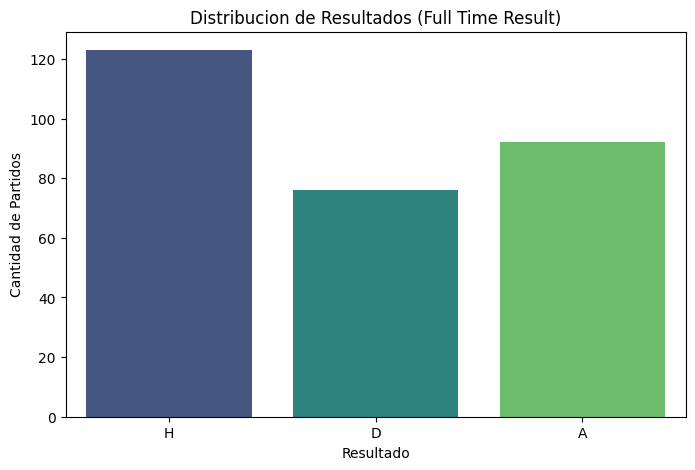

In [10]:
plt.figure(figsize=(8, 5))
sns.countplot(x='ftr', data=df, palette='viridis', order=['H', 'D', 'A'])
plt.title('Distribucion de Resultados (Full Time Result)')
plt.xlabel('Resultado')
plt.ylabel('Cantidad de Partidos')
plt.show()

## 2. Correlacion entre Tiros al Arco y Goles

Segun la documentacion de la API, los tiros al arco (HST/AST) son los mejores predictores.

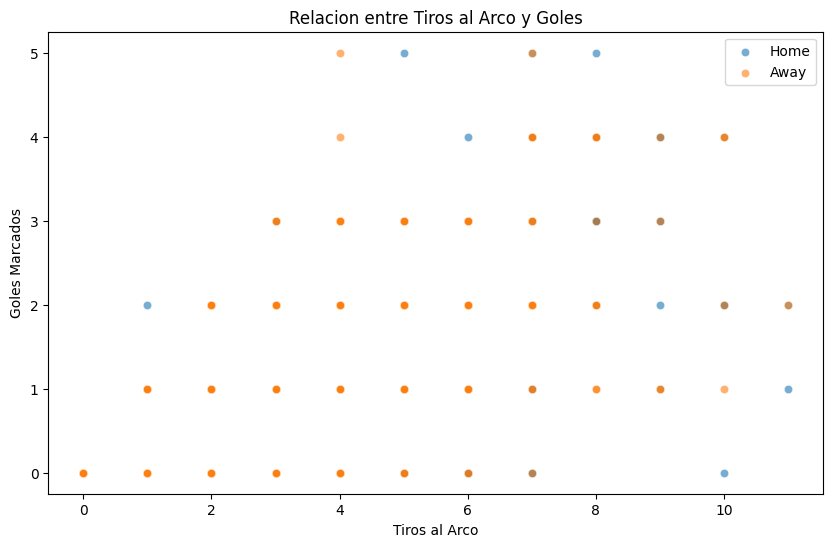

In [11]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='hst', y='fthg', data=df, label='Home', alpha=0.6)
sns.scatterplot(x='ast', y='ftag', data=df, label='Away', alpha=0.6)
plt.title('Relacion entre Tiros al Arco y Goles')
plt.xlabel('Tiros al Arco')
plt.ylabel('Goles Marcados')
plt.legend()
plt.show()

## 3. Comparativa de Cuotas (Bet365 vs Resultados)

Analizamos si las cuotas reflejan bien la probabilidad de victoria.

C:\Users\Arnold's\AppData\Local\Temp\ipykernel_15904\2008813902.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='ftr', y='winner_odds', data=df, palette='Set2')


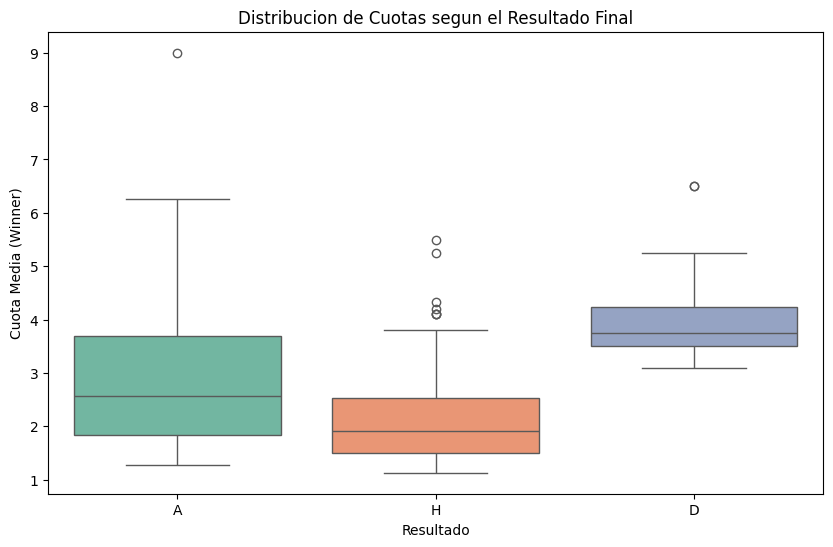

In [12]:
df['winner_odds'] = df.apply(lambda x: x['b365h'] if x['ftr'] == 'H' else (x['b365a'] if x['ftr'] == 'A' else x['b365d']), axis=1)

plt.figure(figsize=(10, 6))
sns.boxplot(x='ftr', y='winner_odds', data=df, palette='Set2')
plt.title('Distribucion de Cuotas segun el Resultado Final')
plt.xlabel('Resultado')
plt.ylabel('Cuota Media (Winner)')
plt.show()

## 4. Prediccion de Goles del Equipo Local (Regresion)

### 4.1 Preparacion de Datos

In [13]:
# Variable objetivo: goles del equipo local (fthg = Full Time Home Goals)
y = df["fthg"].astype(float)

# Features numericas del equipo local
# hs=shots, hst=shots on target, hc=corners, hf=fouls, hy=yellow, hr=red
features = ["hs", "hst", "hc", "hf", "hy", "hr"]
X = df[features].astype(float)

# Verificar que no hay NaNs
print(f"NaN en X: {X.isna().sum().sum()}")
print(f"Shape: X={X.shape}, y={y.shape}")

NaN en X: 0
Shape: X=(291, 6), y=(291,)


### 4.2 Division del Dataset (Train/Test)

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"Train: {len(X_train)} | Test: {len(X_test)}")

Train: 232 | Test: 59


### 4.3 Entrenamiento y Coeficientes

In [15]:
model_lr = LinearRegression()
model_lr.fit(X_train, y_train)

# Predicciones
y_pred = model_lr.predict(X_test)

# Metricas
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"R^2 = {r2:.3f}")
print(f"RMSE = {rmse:.3f}")

# Comparativa Goles Reales vs Esperados (Promedios)
print(f"\nGoles Reales (Promedio Test): {y_test.mean():.2f}")
print(f"Goles Esperados (Promedio Test): {y_pred.mean():.2f}")

# Mostrar coeficientes solicitados
coefs = pd.DataFrame({
    "Feature": features,
    "Coeficiente": model_lr.coef_
}).sort_values("Coeficiente", ascending=False)

print("\nImpacto de las variables (Coeficientes):")
print(coefs.to_string(index=False))
print(f"\nIntercepto: {model_lr.intercept_:.3f}")

R^2 = 0.383
RMSE = 0.984

Goles Reales (Promedio Test): 1.76
Goles Esperados (Promedio Test): 1.49

Impacto de las variables (Coeficientes):
Feature  Coeficiente
    hst     0.326105
     hy     0.025173
     hf    -0.023180
     hs    -0.034720
     hc    -0.046570
     hr    -0.217832

Intercepto: 0.951


### 4.4 Visualizacion de Resultados

Comparamos los goles reales vs. los predichos para evaluar el ajuste del modelo.

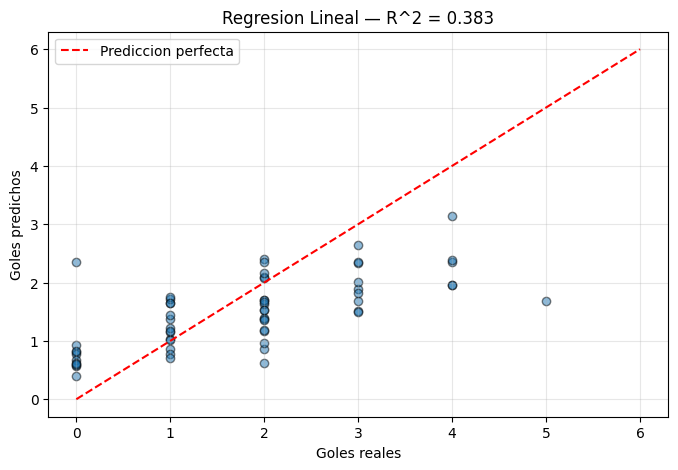

In [16]:
plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred, alpha=0.5, edgecolors='k')
plt.plot([0, 6], [0, 6], 'r--', label='Prediccion perfecta')
plt.xlabel("Goles reales")
plt.ylabel("Goles predichos")
plt.title(f"Regresion Lineal — R^2 = {r2:.3f}")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()